# MLP Neural Network: Boston Crime Shooting Prediction
# DS 4420 Final Project
# SioWa Luo, Li Zou, Shijie Lin

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

## Load Data
Data already cleaned by data_prep.ipynb (SHOOTING harmonized, districts filtered, DAY_OF_WEEK stripped).

In [2]:
def load_data(filepath):
    """
    Load the pre-cleaned combined crime CSV.
    Includes safety cleaning in case CSV predates data_prep fixes.
    """
    df = pd.read_csv(filepath, low_memory = False)

    # Force SHOOTING to integer (handles mixed types from CSV)
    df["SHOOTING"] = pd.to_numeric(df["SHOOTING"], errors = "coerce").fillna(0).astype(int)

    # Strip trailing whitespace from DAY_OF_WEEK
    df["DAY_OF_WEEK"] = df["DAY_OF_WEEK"].str.strip()

    # Drop rare district edge cases
    df = df[~df["DISTRICT"].isin(["External", "Outside of"])]

    # Drop rows missing coordinates
    df = df.dropna(subset = ["Lat", "Long"]).reset_index(drop = True)

    return df

In [3]:
raw = load_data("boston_crime_combined.csv")

print(f"Total records: {len(raw)}")
print(f"Shooting = 1: {raw['SHOOTING'].sum()} ({raw['SHOOTING'].mean()*100:.2f}%)")
print(f"Shooting = 0: {(raw['SHOOTING'] == 0).sum()}")

Total records: 852180
Shooting = 1: 6535 (0.77%)
Shooting = 0: 845645


## Undersample to Balance Classes
Shootings are rare (~0.7%). We undersample the majority class to get a balanced dataset, same approach as our Bayesian model.

In [4]:
np.random.seed(42)

idx_pos = np.where(raw['SHOOTING'].values == 1)[0]
idx_neg = np.where(raw['SHOOTING'].values == 0)[0]

# sample same number of negatives as positives
idx_neg_sampled = np.random.choice(idx_neg, size=len(idx_pos), replace=False)
idx_balanced = np.concatenate([idx_pos, idx_neg_sampled])
np.random.shuffle(idx_balanced)

raw = raw.iloc[idx_balanced].reset_index(drop=True)

print(f'Balanced dataset size: {len(raw)}')
print(f'Shooting = 1: {raw["SHOOTING"].sum()}')
print(f'Shooting = 0: {(raw["SHOOTING"] == 0).sum()}')

Balanced dataset size: 13070
Shooting = 1: 6535
Shooting = 0: 6535


## Feature Engineering

In [5]:
def build_features(df):
    """
    Build feature matrix from raw crime data.

    Features:
      - HOUR, MONTH: cyclical sin/cos encoding
      - DAY_OF_WEEK: one-hot (drop first)
      - DISTRICT: one-hot (drop first)
      - Lat, Long: raw coordinates (standardized later)
    """
    features = pd.DataFrame()

    # Cyclical encoding for hour (0-23) and month (1-12)
    features["hour_sin"] = np.sin(2 * np.pi * df["HOUR"] / 24)
    features["hour_cos"] = np.cos(2 * np.pi * df["HOUR"] / 24)
    features["month_sin"] = np.sin(2 * np.pi * df["MONTH"] / 12)
    features["month_cos"] = np.cos(2 * np.pi * df["MONTH"] / 12)

    # One-hot encode day of week
    day_dummies = pd.get_dummies(df["DAY_OF_WEEK"], prefix = "day", drop_first = True)
    features = pd.concat([features, day_dummies], axis = 1)

    # One-hot encode district
    dist_dummies = pd.get_dummies(df["DISTRICT"], prefix = "dist", drop_first = True)
    features = pd.concat([features, dist_dummies], axis = 1)

    # Geographic coordinates
    features["lat"] = df["Lat"].values
    features["long"] = df["Long"].values

    return features

In [6]:
X_df = build_features(raw)
y = raw["SHOOTING"].values

print(f"Feature matrix: {X_df.shape[0]} rows x {X_df.shape[1]} features")
print(f"Features: {list(X_df.columns)}")

Feature matrix: 13070 rows x 23 features
Features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'dist_A15', 'dist_A7', 'dist_B2', 'dist_B3', 'dist_C11', 'dist_C6', 'dist_D14', 'dist_D4', 'dist_E13', 'dist_E18', 'dist_E5', 'lat', 'long']


## Train / Test Split and Standardization

In [7]:
def train_test_split(X, y, test_ratio = 0.2, seed = 42):
    """Randomly split data into train and test sets."""
    rng = np.random.RandomState(seed)
    indices = rng.permutation(len(y))
    split = int(len(y) * (1 - test_ratio))

    return X[indices[:split]], X[indices[split:]], y[indices[:split]], y[indices[split:]]

In [8]:
def standardize(X_train, X_test):
    """Standardize to zero mean, unit variance. Fit on train only."""
    mean = X_train.mean(axis = 0)
    std = X_train.std(axis = 0)
    std[std == 0] = 1.0

    return (X_train - mean) / std, (X_test - mean) / std

In [9]:
X = X_df.values.astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train, X_test = standardize(X_train, X_test)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% shooting)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% shooting)")

Train: 10456 samples (49.89% shooting)
Test:  2614 samples (50.46% shooting)


## MLP Implementation

In [10]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [11]:
def initialize_weights(layer_dims, seed = 42):
    """He initialization: scale by sqrt(2 / fan_in), good for ReLU."""
    rng = np.random.RandomState(seed)
    params = {}

    for l in range(1, len(layer_dims)):
        scale = np.sqrt(2.0 / layer_dims[l - 1])
        params[f"W{l}"] = rng.randn(layer_dims[l - 1], layer_dims[l]) * scale
        params[f"b{l}"] = np.zeros((1, layer_dims[l]))

    return params

In [12]:
def forward_pass(X, params, n_layers):
    """Forward prop: ReLU hidden layers, sigmoid output. Returns predictions and cache."""
    cache = {"A0": X}

    for l in range(1, n_layers):
        Z = cache[f"A{l-1}"] @ params[f"W{l}"] + params[f"b{l}"]
        cache[f"Z{l}"] = Z
        cache[f"A{l}"] = relu(Z)

    Z_out = cache[f"A{n_layers-1}"] @ params[f"W{n_layers}"] + params[f"b{n_layers}"]
    cache[f"Z{n_layers}"] = Z_out
    cache[f"A{n_layers}"] = sigmoid(Z_out)

    return cache[f"A{n_layers}"], cache

In [13]:
def compute_loss(y_true, y_pred):
    """Binary cross-entropy loss."""
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    bce = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return np.mean(bce)


In [14]:
def backward_pass(y_true, params, cache, n_layers):
    """Backpropagation."""
    grads = {}
    m = y_true.shape[0]
    y_col = y_true.reshape(-1, 1)

    # Output layer
    dZ = cache[f"A{n_layers}"] - y_col
    grads[f"dW{n_layers}"] = (cache[f"A{n_layers-1}"].T @ dZ) / m
    grads[f"db{n_layers}"] = np.mean(dZ, axis = 0, keepdims = True)

    # Hidden layers
    for l in range(n_layers - 1, 0, -1):
        dA = dZ @ params[f"W{l+1}"].T
        dZ = dA * relu_derivative(cache[f"Z{l}"])
        grads[f"dW{l}"] = (cache[f"A{l-1}"].T @ dZ) / m
        grads[f"db{l}"] = np.mean(dZ, axis = 0, keepdims = True)

    return grads


In [15]:
def update_params(params, grads, lr, n_layers):
    """Gradient descent step."""
    for l in range(1, n_layers + 1):
        params[f"W{l}"] -= lr * grads[f"dW{l}"]
        params[f"b{l}"] -= lr * grads[f"db{l}"]

    return params

## Training Loop

In [16]:
def train_mlp(X_train, y_train, X_test, y_test,
              hidden_layers = [64, 32], lr = 0.01, epochs = 200,
              batch_size = 256, seed = 42, verbose = True):
    """
    Train MLP with mini-batch gradient descent.
    Returns trained params, number of layers, and loss history.
    """
    n_features = X_train.shape[1]
    layer_dims = [n_features] + hidden_layers + [1]
    n_layers = len(layer_dims) - 1

    params = initialize_weights(layer_dims, seed = seed)
    history = {"train_loss": [], "test_loss": []}
    rng = np.random.RandomState(seed)

    for epoch in range(epochs):
        # Shuffle and mini-batch update
        perm = rng.permutation(len(y_train))
        X_s, y_s = X_train[perm], y_train[perm]

        for start in range(0, len(y_train), batch_size):
            end = min(start + batch_size, len(y_train))
            y_pred, cache = forward_pass(X_s[start:end], params, n_layers)
            grads = backward_pass(y_s[start:end], params, cache, n_layers)
            params = update_params(params, grads, lr, n_layers)

        # Track loss every 10 epochs
        if epoch % 10 == 0 or epoch == epochs - 1:
            tr_p, _ = forward_pass(X_train, params, n_layers)
            te_p, _ = forward_pass(X_test, params, n_layers)
            history["train_loss"].append(compute_loss(y_train, tr_p.flatten()))
            history["test_loss"].append(compute_loss(y_test, te_p.flatten()))

        # Print every 50 epochs
        if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
            print(f"  Epoch {epoch:3d}: train={history['train_loss'][-1]:.4f}  test={history['test_loss'][-1]:.4f}")

    return params, n_layers, history


In [17]:
# Train the model
params, n_layers, history = train_mlp(
    X_train, y_train, X_test, y_test,
    hidden_layers = [64, 32],
    lr = 0.01,
    epochs = 200,
    batch_size = 256
)


  Epoch   0: train=0.7486  test=0.7446
  Epoch  50: train=0.5477  test=0.5614
  Epoch 100: train=0.5335  test=0.5543
  Epoch 150: train=0.5251  test=0.5514
  Epoch 199: train=0.5188  test=0.5493


## Training Loss Curve

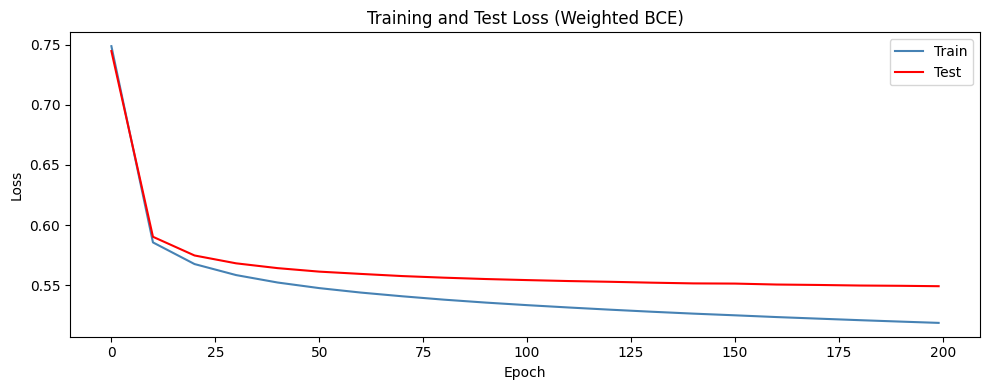

In [18]:
epoch_ticks = list(range(0, 200, 10)) + [199]

fig, ax = plt.subplots(figsize = (10, 4))
ax.plot(epoch_ticks, history["train_loss"], color = "steelblue", label = "Train")
ax.plot(epoch_ticks, history["test_loss"], color = "red", label = "Test")
ax.set_title("Training and Test Loss (Weighted BCE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [19]:
def evaluate(y_true, y_prob, threshold = 0.5):
    """Compute accuracy, precision, recall, F1, and confusion matrix."""
    y_pred = (y_prob >= threshold).astype(int)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "accuracy": (tp + tn) / len(y_true),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion": {"TP": tp, "FP": fp, "TN": tn, "FN": fn}
    }

## Threshold Tuning
Default 0.5 is not optimal for imbalanced data. Sweep to maximize F1.

In [20]:
# Get test predictions
y_test_prob, _ = forward_pass(X_test, params, n_layers)
y_test_prob = y_test_prob.flatten()

# Sweep thresholds
thresholds = np.arange(0.05, 0.96, 0.05)
f1_scores, recall_scores, precision_scores = [], [], []

for t in thresholds:
    m = evaluate(y_test, y_test_prob, threshold = t)
    f1_scores.append(m["f1"])
    recall_scores.append(m["recall"])
    precision_scores.append(m["precision"])

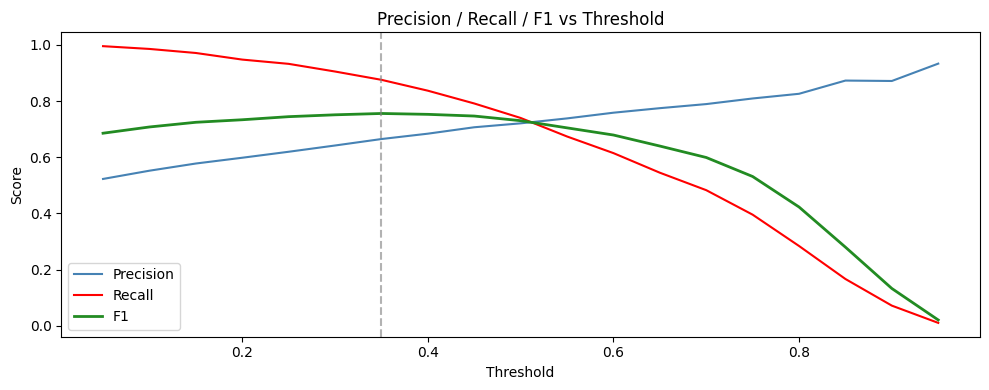

Best F1 threshold: 0.35


In [21]:
fig, ax = plt.subplots(figsize = (10, 4))
ax.plot(thresholds, precision_scores, color = "steelblue", label = "Precision")
ax.plot(thresholds, recall_scores, color = "red", label = "Recall")
ax.plot(thresholds, f1_scores, color = "forestgreen", linewidth = 2, label = "F1")

# Mark best F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
ax.axvline(best_threshold, color = "gray", linestyle = "--", alpha = 0.6)

ax.set_title("Precision / Recall / F1 vs Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_threshold:.2f}")

In [22]:
# Evaluate at optimal threshold
metrics_best = evaluate(y_test, y_test_prob, threshold = best_threshold)

print(f"Test Evaluation (threshold = {best_threshold:.2f}):")
print(f"  Accuracy:  {metrics_best['accuracy']:.4f}")
print(f"  Precision: {metrics_best['precision']:.4f}")
print(f"  Recall:    {metrics_best['recall']:.4f}")
print(f"  F1 Score:  {metrics_best['f1']:.4f}")
print(f"  Confusion: {metrics_best['confusion']}")

Test Evaluation (threshold = 0.35):
  Accuracy:  0.7146
  Precision: 0.6649
  Recall:    0.8757
  F1 Score:  0.7559
  Confusion: {'TP': 1155, 'FP': 582, 'TN': 713, 'FN': 164}


## Architecture Comparison
Compare different network depths and widths to show tuning decisions.

In [23]:
architectures = [
    {"name": "Shallow (32)",      "layers": [32]},
    {"name": "Medium (64, 32)",   "layers": [64, 32]},
    {"name": "Deep (64, 32, 16)", "layers": [64, 32, 16]},
]

arch_results = []

for arch in architectures:
    print(f"Training {arch['name']}...")

    p, nl, _ = train_mlp(
        X_train, y_train, X_test, y_test,
        hidden_layers = arch["layers"],
        lr = 0.01, epochs = 200, batch_size = 256, verbose = False
    )

    probs, _ = forward_pass(X_test, p, nl)
    m = evaluate(y_test, probs.flatten(), threshold = best_threshold)

    arch_results.append({
        "Architecture": arch["name"],
        "F1": m["f1"], "Precision": m["precision"],
        "Recall": m["recall"], "Accuracy": m["accuracy"],
    })

print()


Training Shallow (32)...
Training Medium (64, 32)...
Training Deep (64, 32, 16)...



In [24]:
arch_df = pd.DataFrame(arch_results).sort_values("F1", ascending = False).reset_index(drop = True)

print("Architecture Comparison:")
print(arch_df.to_string(index = False, float_format = lambda x: f"{x:.4f}"))

Architecture Comparison:
     Architecture     F1  Precision  Recall  Accuracy
  Medium (64, 32) 0.7559     0.6649  0.8757    0.7146
     Shallow (32) 0.7537     0.6628  0.8734    0.7119
Deep (64, 32, 16) 0.7522     0.6606  0.8734    0.7096


### Model Summary

All three architectures performed similarly, with F1 scores around 0.75 and recall near 0.87. The medium architecture (64-32) edged out the others slightly and was used as the final model.